In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn import metrics
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree

import warnings
warnings.filterwarnings('ignore')


In [2]:
url = 'credit.csv'
creditData = pd.read_csv(url)
creditData.head(3)

,checking_balance,months_loan_duration,credit_history,purpose,amount,savings_balance,employment_duration,percent_of_income,years_at_residence,age,other_credit,housing,existing_loans_count,job,dependents,phone,default
0,< 0 DM,6,critical,furniture/appliances,1169,unknown,> 7 years,4,4,67,none,own,2,skilled,1,yes,no
1,1 - 200 DM,48,good,furniture/appliances,5951,< 100 DM,1 - 4 years,2,2,22,none,own,1,skilled,1,no,yes
2,unknown,12,critical,education,2096,< 100 DM,4 - 7 years,2,3,49,none,own,1,unskilled,2,no,no


In [3]:
creditData.shape

(1000, 17)

In [4]:
creditData['default'].value_counts()

default
no     700
yes    300
Name: count, dtype: int64

In [5]:
creditData.describe().T

,count,mean,std,min,25%,50%,75%,max
months_loan_duration,1000.0,20.903,12.058814,4.0,12.0,18.0,24.00,72.0
amount,1000.0,3271.258,2822.736876,250.0,1365.5,2319.5,3972.25,18424.0
percent_of_income,1000.0,2.973,1.118715,1.0,2.0,3.0,4.00,4.0
years_at_residence,1000.0,2.845,1.103718,1.0,2.0,3.0,4.00,4.0
age,1000.0,35.546,11.375469,19.0,27.0,33.0,42.00,75.0
existing_loans_count,1000.0,1.407,0.577654,1.0,1.0,1.0,2.00,4.0
dependents,1000.0,1.155,0.362086,1.0,1.0,1.0,1.00,2.0


In [6]:
creditData.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   checking_balance      1000 non-null   object
 1   months_loan_duration  1000 non-null   int64 
 2   credit_history        1000 non-null   object
 3   purpose               1000 non-null   object
 4   amount                1000 non-null   int64 
 5   savings_balance       1000 non-null   object
 6   employment_duration   1000 non-null   object
 7   percent_of_income     1000 non-null   int64 
 8   years_at_residence    1000 non-null   int64 
 9   age                   1000 non-null   int64 
 10  other_credit          1000 non-null   object
 11  housing               1000 non-null   object
 12  existing_loans_count  1000 non-null   int64 
 13  job                   1000 non-null   object
 14  dependents            1000 non-null   int64 
 15  phone                 1000 non-null   o

In [7]:
# convert object columns into categorical
for feature in creditData.columns:
    if creditData[feature].dtype == 'object':
        creditData[feature] = pd.Categorical(creditData[feature])
creditData.head(3)

,checking_balance,months_loan_duration,credit_history,purpose,amount,savings_balance,employment_duration,percent_of_income,years_at_residence,age,other_credit,housing,existing_loans_count,job,dependents,phone,default
0,< 0 DM,6,critical,furniture/appliances,1169,unknown,> 7 years,4,4,67,none,own,2,skilled,1,yes,no
1,1 - 200 DM,48,good,furniture/appliances,5951,< 100 DM,1 - 4 years,2,2,22,none,own,1,skilled,1,no,yes
2,unknown,12,critical,education,2096,< 100 DM,4 - 7 years,2,3,49,none,own,1,unskilled,2,no,no


In [8]:
value_cnts = ['checking_balance','credit_history',
              'purpose','savings_balance',
              'savings_balance','employment_duration',
              'other_credit','housing',
              'job','phone']
for x in value_cnts:
    print(creditData[x].value_counts())

checking_balance
unknown       394
< 0 DM        274
1 - 200 DM    269
> 200 DM       63
Name: count, dtype: int64
credit_history
good         530
critical     293
poor          88
very good     49
perfect       40
Name: count, dtype: int64
purpose
furniture/appliances    473
car                     337
business                 97
education                59
renovations              22
car0                     12
Name: count, dtype: int64
savings_balance
< 100 DM         603
unknown          183
100 - 500 DM     103
500 - 1000 DM     63
> 1000 DM         48
Name: count, dtype: int64
savings_balance
< 100 DM         603
unknown          183
100 - 500 DM     103
500 - 1000 DM     63
> 1000 DM         48
Name: count, dtype: int64
employment_duration
1 - 4 years    339
> 7 years      253
4 - 7 years    174
< 1 year       172
unemployed      62
Name: count, dtype: int64
other_credit
none     814
bank     139
store     47
Name: count, dtype: int64
housing
own      713
rent     179
other    1

In [9]:
# preform one hot encoding on category columns
replaceStruct = {
                "checking_balance":     {"< 0 DM": 1, "1 - 200 DM": 2 ,"> 200 DM": 3 ,"unknown":-1},
                "credit_history": {"critical": 1, "poor":2 , "good": 3, "very good": 4,"perfect": 5},
                 "savings_balance": {"< 100 DM": 1, "100 - 500 DM":2 , "500 - 1000 DM": 3, "> 1000 DM": 4,"unknown": -1},
                 "employment_duration":     {"unemployed": 1, "< 1 year": 2 ,"1 - 4 years": 3 ,"4 - 7 years": 4 ,"> 7 years": 5},
                "phone":     {"no": 1, "yes": 2 },
                "job":     {"unemployed": 1, "unskilled": 2, "skilled": 3, "management": 4 },
                "default":     {"no": 0, "yes": 1 } 
                    }
oneHotCols=["purpose","housing","other_credit","job"]


In [10]:
creditData = creditData.replace(replaceStruct)
creditData=pd.get_dummies(creditData, columns=oneHotCols)
creditData.head(3)

,checking_balance,months_loan_duration,credit_history,amount,savings_balance,employment_duration,percent_of_income,years_at_residence,age,existing_loans_count,...,housing_other,housing_own,housing_rent,other_credit_bank,other_credit_none,other_credit_store,job_4,job_3,job_1,job_2
0,1,6,1,1169,-1,5,4,4,67,2,...,False,True,False,False,True,False,False,True,False,False
1,2,48,3,5951,1,3,2,2,22,1,...,False,True,False,False,True,False,False,True,False,False
2,-1,12,1,2096,1,4,2,3,49,1,...,False,True,False,False,True,False,False,False,False,True


In [11]:
# 209 columns are now in the dataframe
creditData.shape

(1000, 29)

## Split Data

In [12]:
X = creditData.drop('default', axis=1)
y = creditData['default']
(X_train, X_test,
 y_train, y_test) = train_test_split(X,
                                     y,
                                     test_size=0.3,
                                     random_state=1)

## Build a Decision Tree

In [13]:
dTree = DecisionTreeClassifier(criterion='gini',
                               random_state=1)
dTree.fit(X_train,y_train)

DecisionTreeClassifier(random_state=1)

## Score the Decision Tree

In [14]:
print(f'Accuracy on train: {dTree.score(X_train,y_train)}')
print(f'Accuracy on test: {dTree.score(X_test, y_test)}')

Accuracy on train: 1.0
Accuracy on test: 0.6933333333333334


In [15]:
#Checking number of positives
y.value_counts()

default
0    700
1    300
Name: count, dtype: int64

In [16]:
## Function to create confusion matrix
def make_confusion_matrix(model,y_actual,labels=[1, 0]):
    '''
    model : classifier to predict values of X
    y_actual : ground truth  
    
    '''
    y_predict = model.predict(X_test)
    cm=metrics.confusion_matrix( y_actual, y_predict, labels=[0, 1])
    df_cm = pd.DataFrame(cm, index = [i for i in ["Actual - No","Actual - Yes"]],
                  columns = [i for i in ['Predicted - No','Predicted - Yes']])
    group_counts = ["{0:0.0f}".format(value) for value in
                cm.flatten()]
    group_percentages = ["{0:.2%}".format(value) for value in
                         cm.flatten()/np.sum(cm)]
    labels = [f"{v1}\n{v2}" for v1, v2 in
              zip(group_counts,group_percentages)]
    labels = np.asarray(labels).reshape(2,2)
    plt.figure(figsize = (10,7))
    sns.heatmap(df_cm, annot=labels,fmt='')
    plt.ylabel('True label')
    plt.xlabel('Predicted label')

In [17]:
##  Function to calculate recall score
def get_recall_score(model):
    '''
    model : classifier to predict values of X

    '''
    pred_train = model.predict(X_train)
    pred_test = model.predict(X_test)
    print("Recall on training set : ",metrics.recall_score(y_train,pred_train))
    print("Recall on test set : ",metrics.recall_score(y_test,pred_test))

## Confusion Matrix

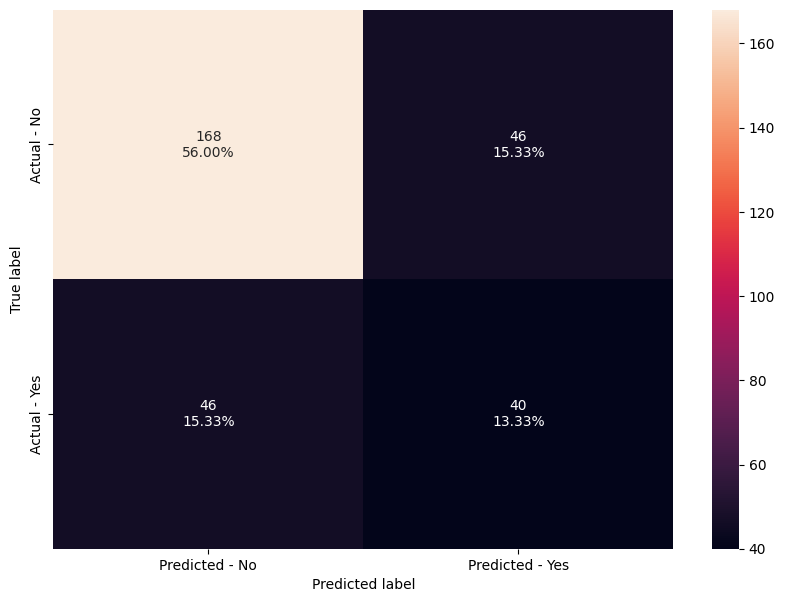

In [18]:
make_confusion_matrix(dTree, y_test)

In [19]:
get_recall_score(dTree)

Recall on training set :  1.0
Recall on test set :  0.46511627906976744


## Visualizing the Decision Tree

In [20]:
feature_names = list(X.columns)
print(feature_names)

['checking_balance', 'months_loan_duration', 'credit_history', 'amount', 'savings_balance', 'employment_duration', 'percent_of_income', 'years_at_residence', 'age', 'existing_loans_count', 'dependents', 'phone', 'purpose_business', 'purpose_car', 'purpose_car0', 'purpose_education', 'purpose_furniture/appliances', 'purpose_renovations', 'housing_other', 'housing_own', 'housing_rent', 'other_credit_bank', 'other_credit_none', 'other_credit_store', 'job_4', 'job_3', 'job_1', 'job_2']


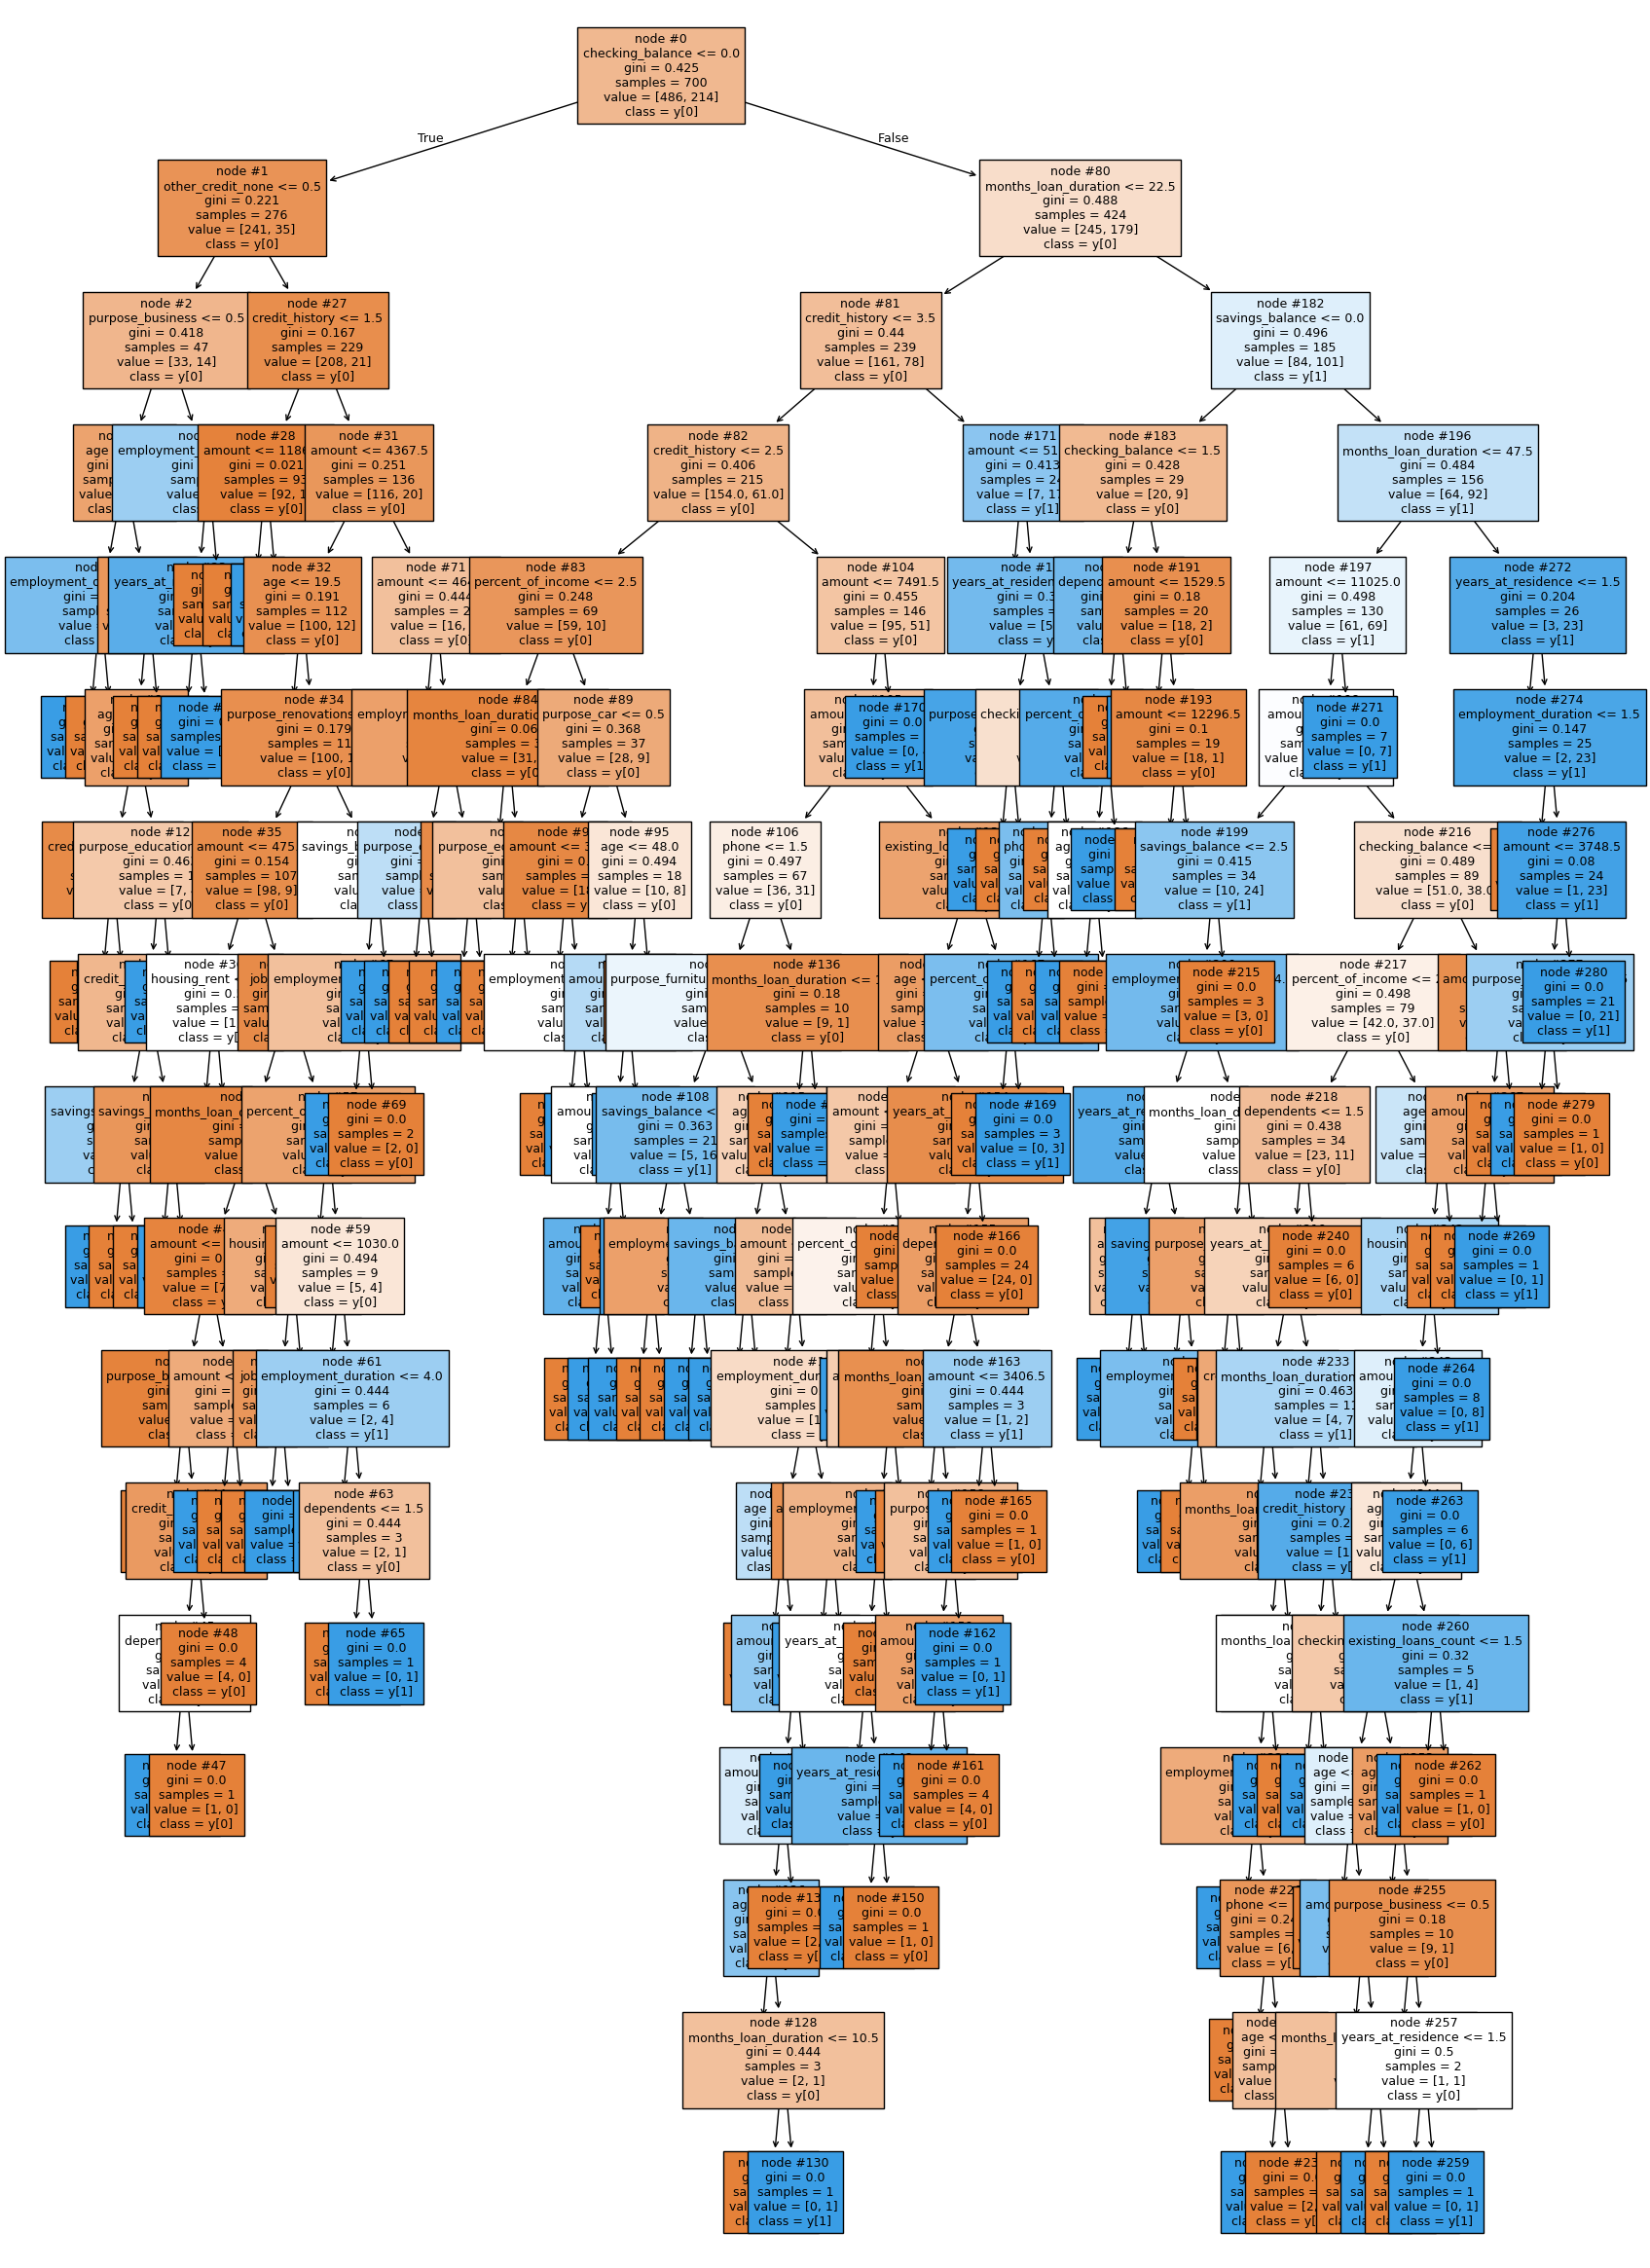

In [21]:
plt.figure(figsize=(20,30))
tree.plot_tree(dTree, 
               feature_names=feature_names,
               filled=True,
               fontsize=9,
               node_ids=True,
               class_names=True)
plt.show()

In [22]:
print(tree.export_text(dTree,feature_names=feature_names,show_weights=True))

|--- checking_balance <= 0.00
|   |--- other_credit_none <= 0.50
|   |   |--- purpose_business <= 0.50
|   |   |   |--- age <= 25.50
|   |   |   |   |--- employment_duration <= 3.50
|   |   |   |   |   |--- weights: [0.00, 3.00] class: 1
|   |   |   |   |--- employment_duration >  3.50
|   |   |   |   |   |--- weights: [1.00, 0.00] class: 0
|   |   |   |--- age >  25.50
|   |   |   |   |--- age <= 38.50
|   |   |   |   |   |--- age <= 31.50
|   |   |   |   |   |   |--- credit_history <= 4.50
|   |   |   |   |   |   |   |--- weights: [13.00, 0.00] class: 0
|   |   |   |   |   |   |--- credit_history >  4.50
|   |   |   |   |   |   |   |--- weights: [0.00, 1.00] class: 1
|   |   |   |   |   |--- age >  31.50
|   |   |   |   |   |   |--- purpose_education <= 0.50
|   |   |   |   |   |   |   |--- credit_history <= 1.50
|   |   |   |   |   |   |   |   |--- savings_balance <= 2.50
|   |   |   |   |   |   |   |   |   |--- weights: [0.00, 2.00] class: 1
|   |   |   |   |   |   |   |   |--- sav

In [23]:
print (pd.DataFrame(dTree.feature_importances_,
                    columns = ['Importances'],
                    index = X_train.columns)
                    .sort_values(by='Importances',
                                 ascending=False))

                              Importances
amount                           0.204163
checking_balance                 0.136840
age                              0.110746
months_loan_duration             0.100323
employment_duration              0.073225
credit_history                   0.065357
savings_balance                  0.057059
years_at_residence               0.052719
percent_of_income                0.034128
purpose_business                 0.023784
dependents                       0.023062
purpose_car                      0.021217
phone                            0.016737
housing_rent                     0.016646
purpose_education                0.013767
existing_loans_count             0.013575
purpose_furniture/appliances     0.012421
other_credit_none                0.011156
job_4                            0.005769
purpose_renovations              0.004489
job_2                            0.002818
other_credit_bank                0.000000
housing_own                      0

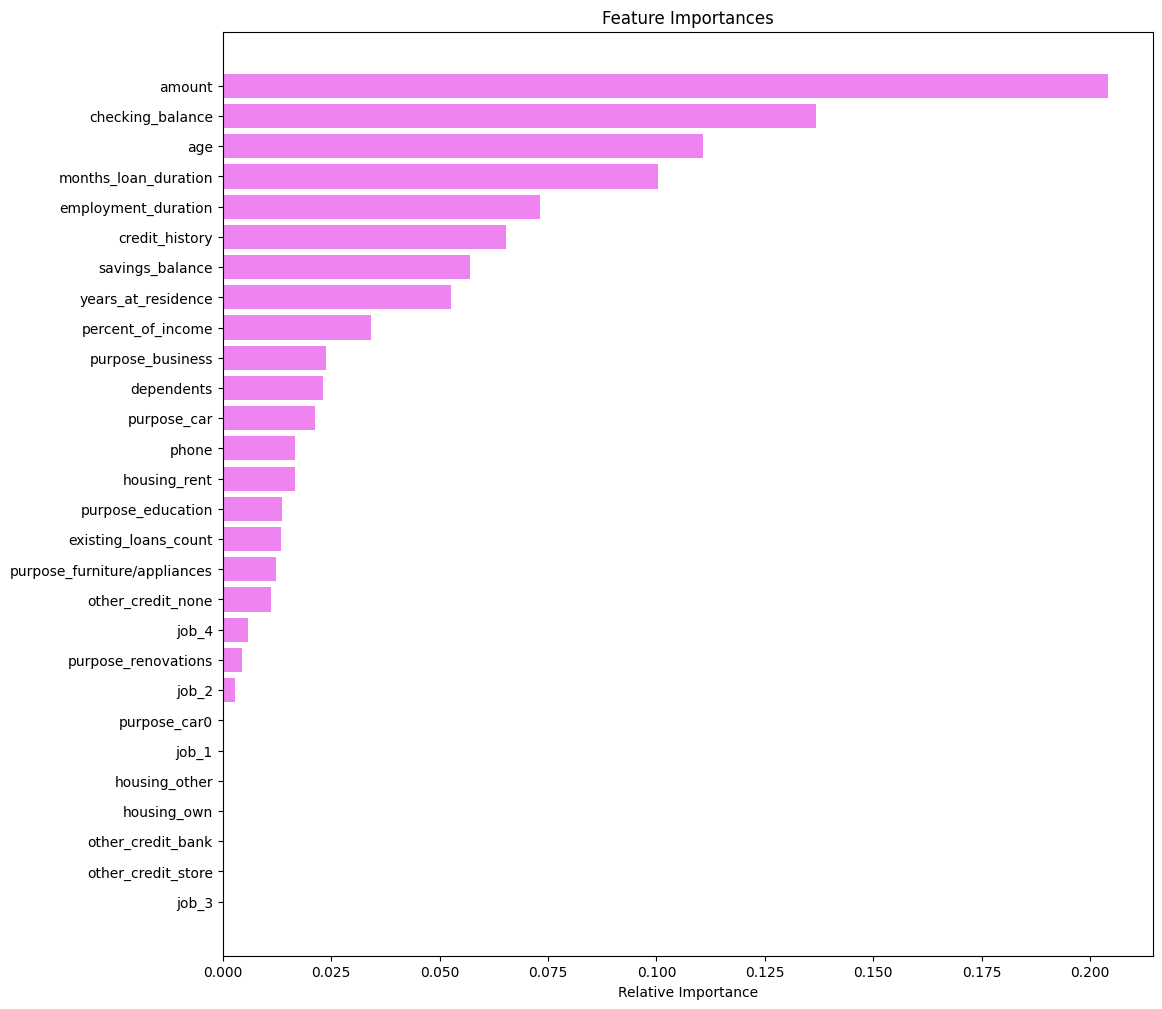

In [24]:
importances = dTree.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(12,12))
plt.title('Feature Importances')
plt.barh(range(len(indices)),
         importances[indices],
         color='violet',
         align='center')
plt.yticks(range(len(indices)), 
           [feature_names[i] for i in indices])
plt.xlabel('Relative Importance')
plt.show()

## Reducing overfitting

In [25]:
dTree1 = DecisionTreeClassifier(criterion='gini',
                                max_depth=3,
                                random_state=1)
dTree1.fit(X_train,y_train)

DecisionTreeClassifier(max_depth=3, random_state=1)

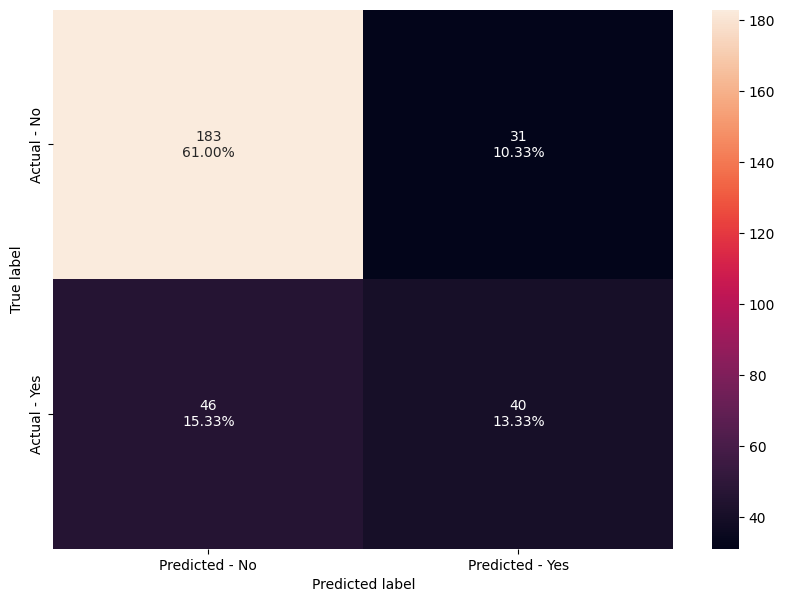

In [26]:
make_confusion_matrix(dTree1, y_test)

In [27]:
print("Accuracy on training set : ",dTree1.score(X_train, y_train))
print("Accuracy on test set : ",dTree1.score(X_test, y_test))
get_recall_score(dTree1)

Accuracy on training set :  0.7528571428571429
Accuracy on test set :  0.7433333333333333
Recall on training set :  0.5373831775700935
Recall on test set :  0.46511627906976744


## Visualizing the Decision Tree

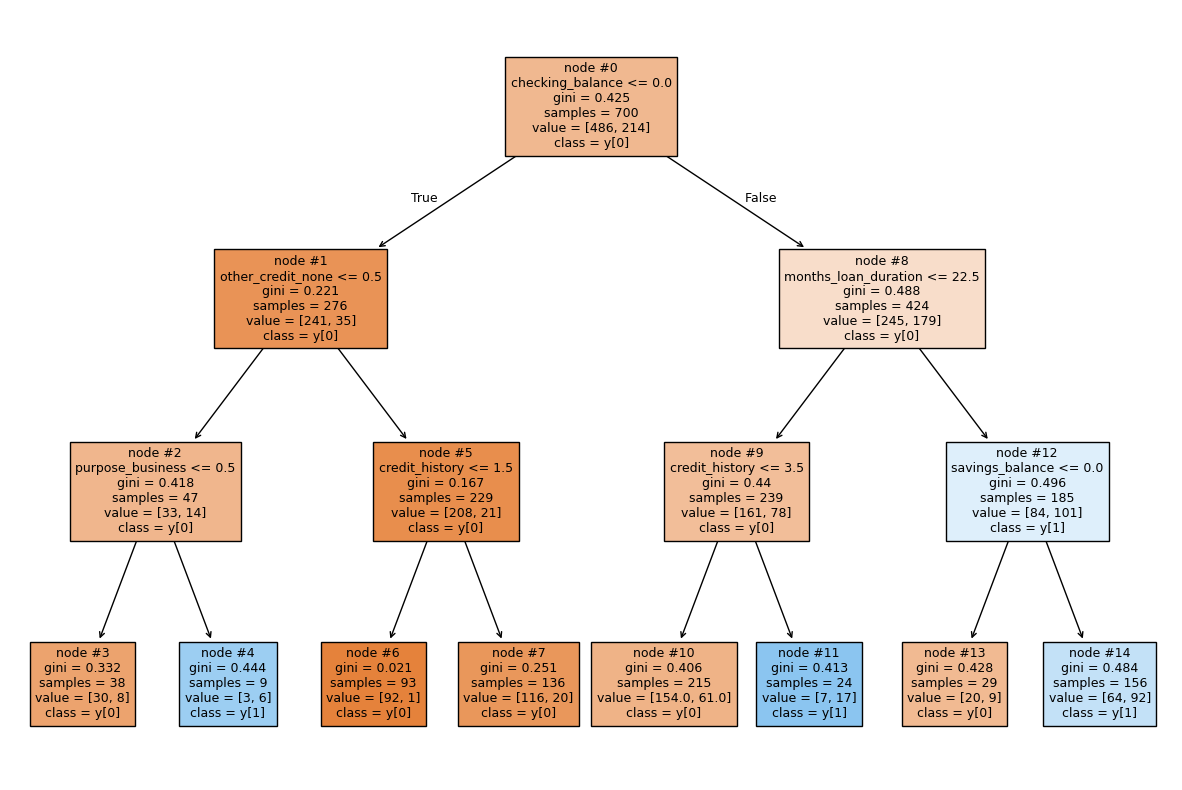

In [28]:
plt.figure(figsize=(15,10))
tree.plot_tree(dTree1,
               feature_names = feature_names,
               filled=True,
               fontsize=9,
               node_ids=True, 
               class_names=True)
plt.show()

In [29]:
print(tree.export_text(dTree1,feature_names=feature_names,show_weights=True))

|--- checking_balance <= 0.00
|   |--- other_credit_none <= 0.50
|   |   |--- purpose_business <= 0.50
|   |   |   |--- weights: [30.00, 8.00] class: 0
|   |   |--- purpose_business >  0.50
|   |   |   |--- weights: [3.00, 6.00] class: 1
|   |--- other_credit_none >  0.50
|   |   |--- credit_history <= 1.50
|   |   |   |--- weights: [92.00, 1.00] class: 0
|   |   |--- credit_history >  1.50
|   |   |   |--- weights: [116.00, 20.00] class: 0
|--- checking_balance >  0.00
|   |--- months_loan_duration <= 22.50
|   |   |--- credit_history <= 3.50
|   |   |   |--- weights: [154.00, 61.00] class: 0
|   |   |--- credit_history >  3.50
|   |   |   |--- weights: [7.00, 17.00] class: 1
|   |--- months_loan_duration >  22.50
|   |   |--- savings_balance <= 0.00
|   |   |   |--- weights: [20.00, 9.00] class: 0
|   |   |--- savings_balance >  0.00
|   |   |   |--- weights: [64.00, 92.00] class: 1



In [30]:
print(pd.DataFrame(dTree1.feature_importances_,
                   columns = ['Importances'],
                   index = X_train.columns)
                   .sort_values(by='Importances',
                                ascending=False))

                              Importances
checking_balance                 0.492510
months_loan_duration             0.169806
credit_history                   0.166109
savings_balance                  0.064467
other_credit_none                0.055977
purpose_business                 0.051129
purpose_furniture/appliances     0.000000
job_1                            0.000000
job_3                            0.000000
job_4                            0.000000
other_credit_store               0.000000
other_credit_bank                0.000000
housing_rent                     0.000000
housing_own                      0.000000
housing_other                    0.000000
purpose_renovations              0.000000
purpose_car0                     0.000000
purpose_education                0.000000
purpose_car                      0.000000
phone                            0.000000
dependents                       0.000000
existing_loans_count             0.000000
age                              0

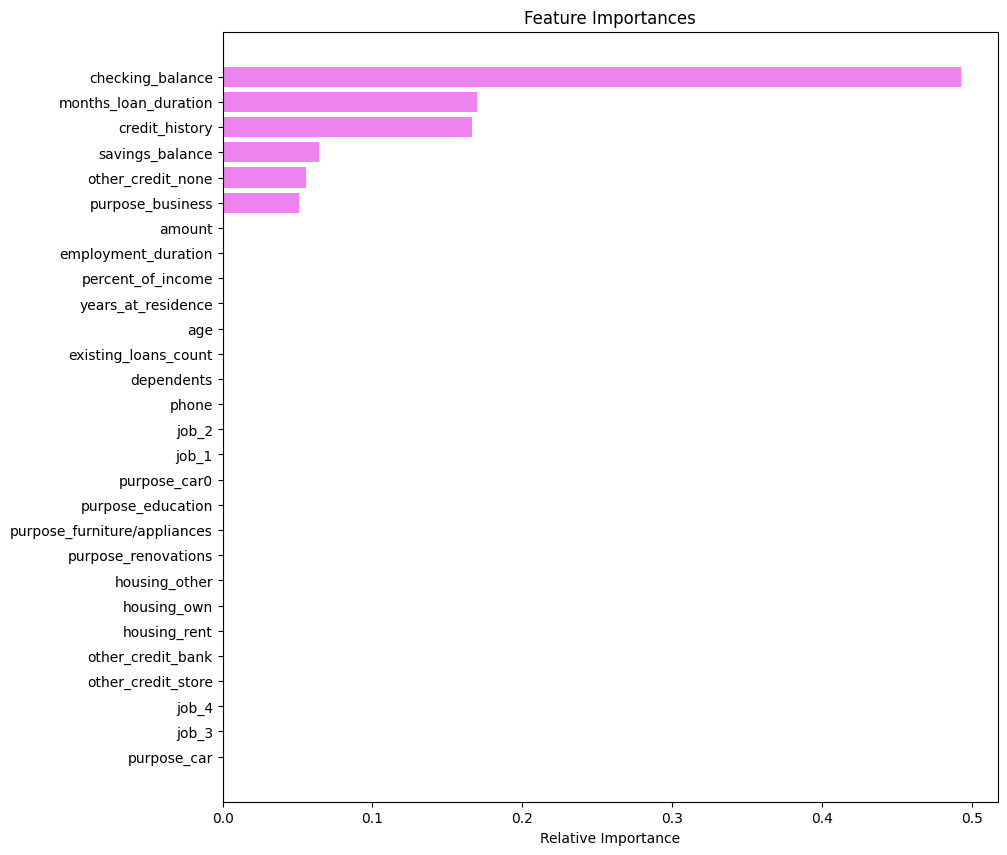

In [31]:
importances = dTree1.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(10,10))
plt.title('Feature Importances')
plt.barh(range(len(indices)),
         importances[indices],
         color='violet',
         align='center')
plt.yticks(range(len(importances)),
           [feature_names[i] for i in indices])
plt.xlabel('Relative Importance')
plt.show()

## Use GridSearch for Hyperparameter tuning of our tree model

In [32]:
from sklearn.model_selection import GridSearchCV

In [33]:
estimator = DecisionTreeClassifier(random_state=1)

parameter = {'max_depth':np.arange(1,10),
             'min_samples_leaf': [1,2,5,7,10,15,20],
             'max_leaf_nodes':[2,3,5,10],
             'min_impurity_decrease':[0.001,0.01,0.1]}

acc_scorer = metrics.make_scorer(metrics.recall_score)

grid_obj = GridSearchCV(estimator,
                        parameter,
                        scoring=acc_scorer,
                        cv=5)
grid_obj = grid_obj.fit(X_train, y_train)

estimator = grid_obj.best_estimator_
estimator.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=4, max_leaf_nodes=10,
                       min_impurity_decrease=0.001, min_samples_leaf=20,
                       random_state=1)

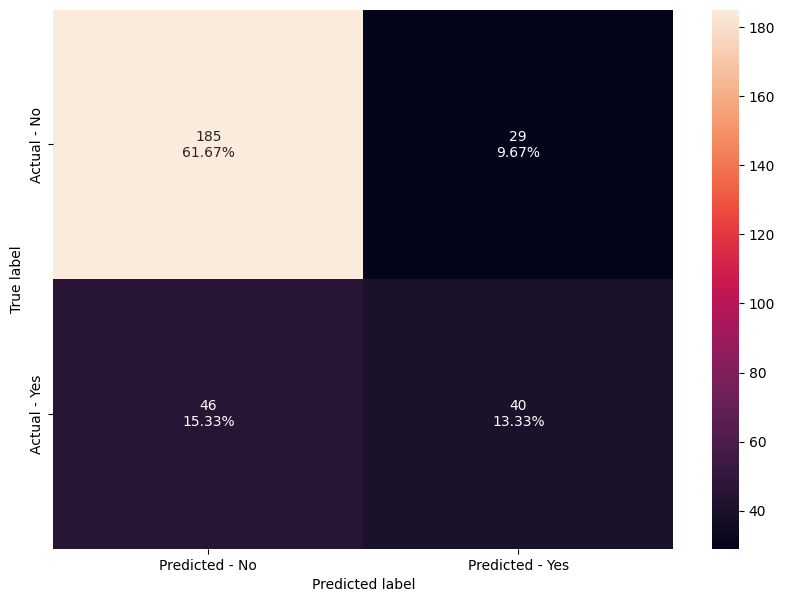

In [34]:
make_confusion_matrix(estimator, y_test)

In [35]:
print("Accuracy on training set : ",estimator.score(X_train, y_train))
print("Accuracy on test set : ",estimator.score(X_test, y_test))
get_recall_score(estimator)

Accuracy on training set :  0.7485714285714286
Accuracy on test set :  0.75
Recall on training set :  0.5093457943925234
Recall on test set :  0.46511627906976744


## Visualizing the Decision Tree

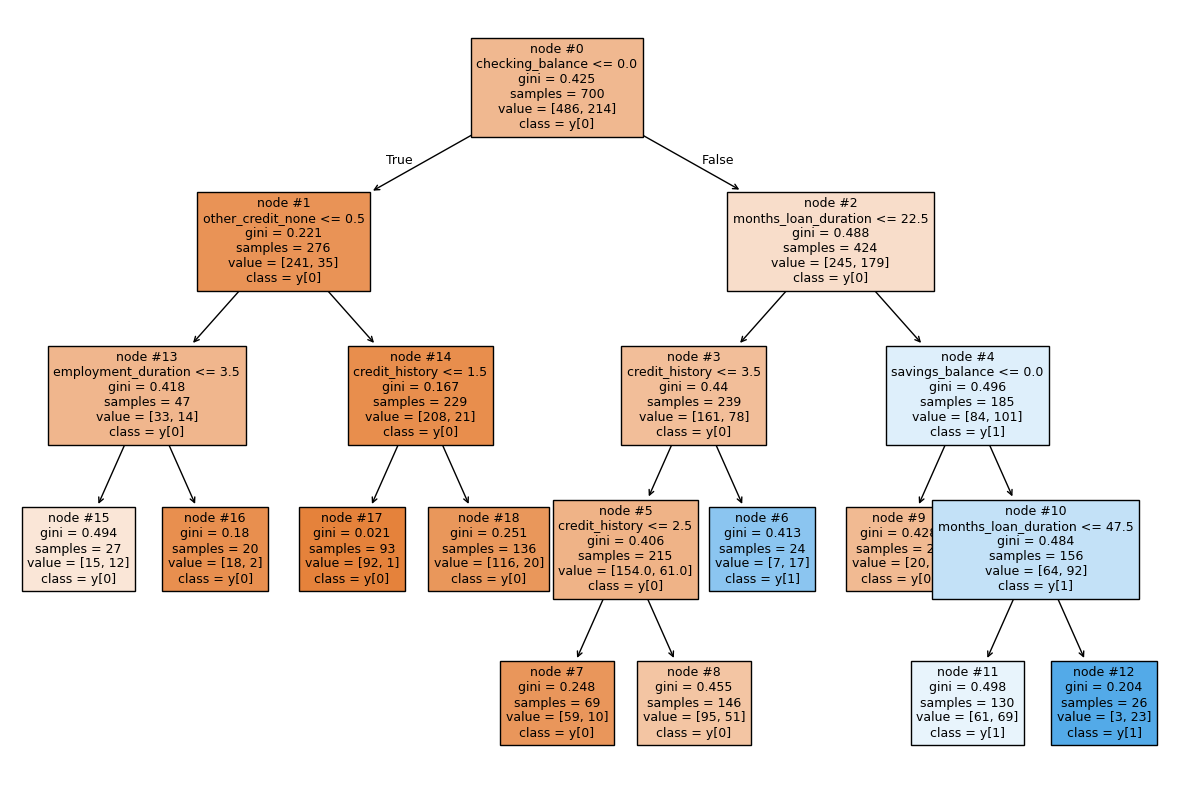

In [36]:
plt.figure(figsize=(15,10))
tree.plot_tree(estimator, 
               feature_names=feature_names,
               filled=True,
               fontsize=9,
               node_ids=True,
               class_names=True)
plt.show()

In [37]:
print(tree.export_text(estimator,feature_names=feature_names,show_weights=True))

|--- checking_balance <= 0.00
|   |--- other_credit_none <= 0.50
|   |   |--- employment_duration <= 3.50
|   |   |   |--- weights: [15.00, 12.00] class: 0
|   |   |--- employment_duration >  3.50
|   |   |   |--- weights: [18.00, 2.00] class: 0
|   |--- other_credit_none >  0.50
|   |   |--- credit_history <= 1.50
|   |   |   |--- weights: [92.00, 1.00] class: 0
|   |   |--- credit_history >  1.50
|   |   |   |--- weights: [116.00, 20.00] class: 0
|--- checking_balance >  0.00
|   |--- months_loan_duration <= 22.50
|   |   |--- credit_history <= 3.50
|   |   |   |--- credit_history <= 2.50
|   |   |   |   |--- weights: [59.00, 10.00] class: 0
|   |   |   |--- credit_history >  2.50
|   |   |   |   |--- weights: [95.00, 51.00] class: 0
|   |   |--- credit_history >  3.50
|   |   |   |--- weights: [7.00, 17.00] class: 1
|   |--- months_loan_duration >  22.50
|   |   |--- savings_balance <= 0.00
|   |   |   |--- weights: [20.00, 9.00] class: 0
|   |   |--- savings_balance >  0.00
|   |  

In [38]:
print(pd.DataFrame(estimator.feature_importances_,
                   columns = ['Imp'],
                   index = X_train.columns)
                   .sort_values(by='Imp',
                                ascending=False))

                                   Imp
checking_balance              0.427296
months_loan_duration          0.226805
credit_history                0.201464
savings_balance               0.055931
other_credit_none             0.048565
employment_duration           0.039938
purpose_furniture/appliances  0.000000
job_1                         0.000000
job_3                         0.000000
job_4                         0.000000
other_credit_store            0.000000
other_credit_bank             0.000000
housing_rent                  0.000000
housing_own                   0.000000
housing_other                 0.000000
purpose_renovations           0.000000
purpose_car0                  0.000000
purpose_education             0.000000
purpose_car                   0.000000
purpose_business              0.000000
phone                         0.000000
dependents                    0.000000
existing_loans_count          0.000000
age                           0.000000
years_at_residence       

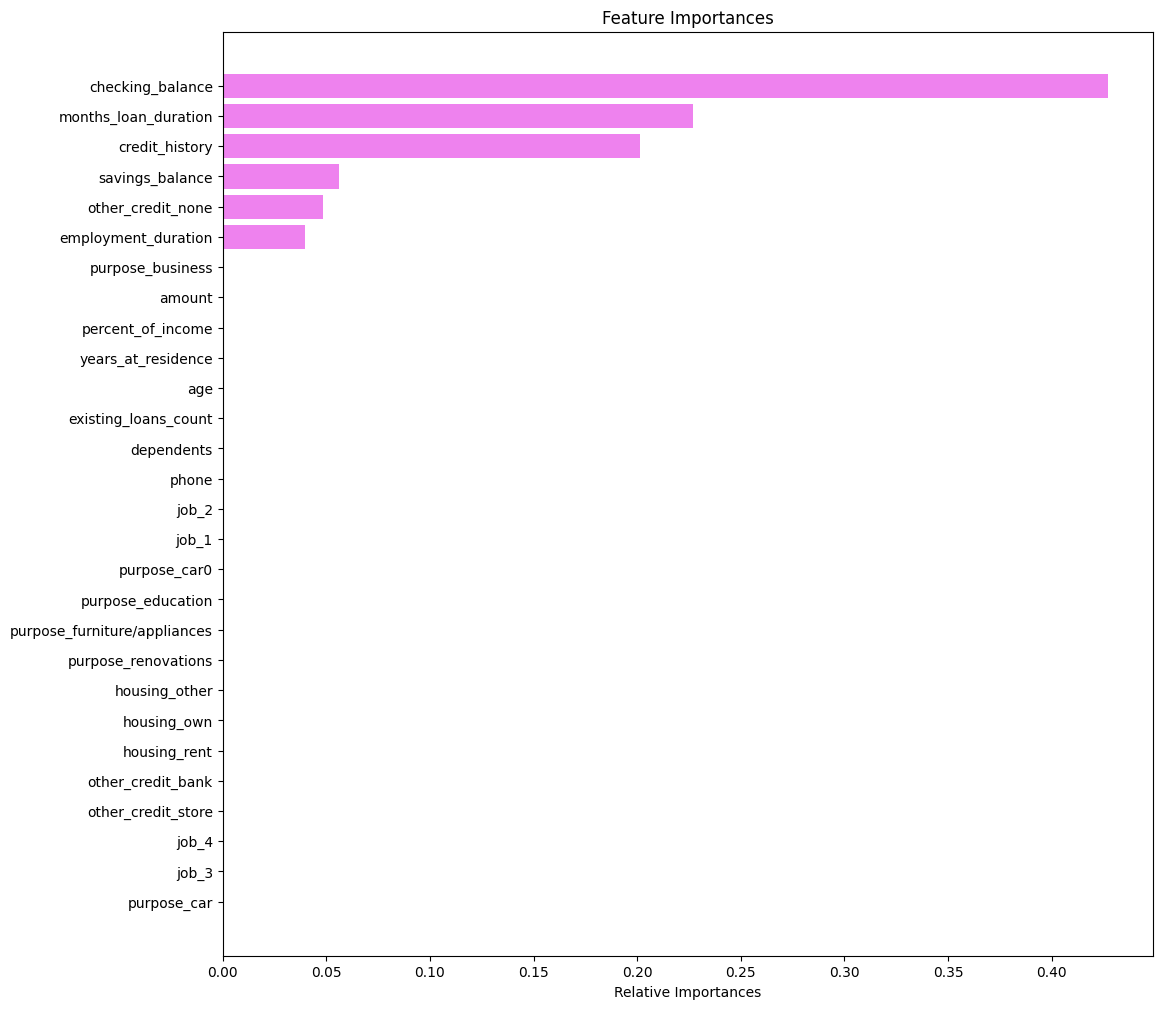

In [39]:
importances = estimator.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(12,12))
plt.title('Feature Importances')
plt.barh(range(len(indices)),
         importances[indices],
         color='violet',
         align='center')
plt.yticks(range(len(indices)),
           [feature_names[i] for i in indices])
plt.xlabel('Relative Importances')
plt.show()

## Pruning

In [45]:
clf = DecisionTreeClassifier(random_state=1)
path = clf.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas, impurities = path.ccp_alphas, path.impurities

In [46]:
pd.DataFrame(path)

,ccp_alphas,impurities
0,0.000000,0.000000
1,0.000940,0.002819
2,0.001224,0.005268
3,0.001250,0.007768
4,0.001250,0.010268
...,...,...
73,0.005618,0.335998
74,0.007117,0.357350
75,0.011122,0.368471
76,0.014366,0.382838


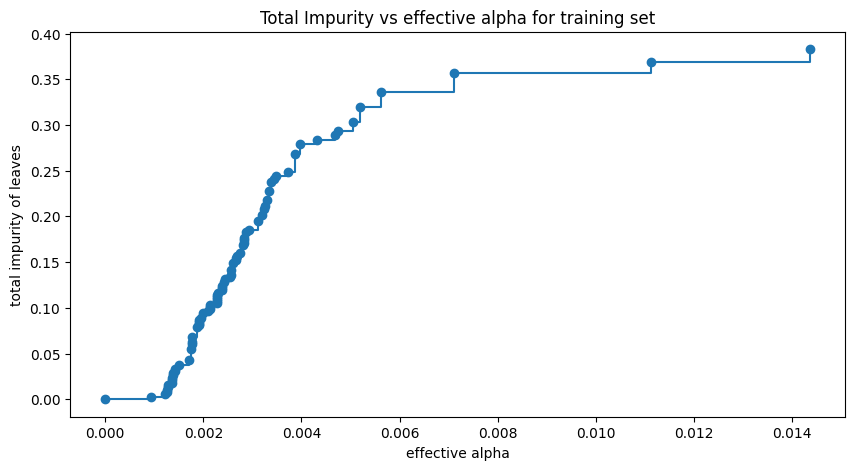

In [47]:
fig, ax = plt.subplots(figsize=(10,5))
ax.plot(ccp_alphas[:-1], impurities[:-1], marker='o', drawstyle="steps-post")
ax.set_xlabel("effective alpha")
ax.set_ylabel("total impurity of leaves")
ax.set_title("Total Impurity vs effective alpha for training set")
plt.show()

In [50]:
clfs = []
for ccp_alpha in ccp_alphas:
    clf = DecisionTreeClassifier(random_state=1,
                                 ccp_alpha=ccp_alpha)
    clf.fit(X_train, y_train)
    clfs.append(clf)
print('Number of nodes in the last tree is: {} with ccp_alpha {}'.format(
    clfs[-1].tree_.node_count, ccp_alphas[-1]))

Number of nodes in the last tree is: 1 with ccp_alpha 0.041668413944741134


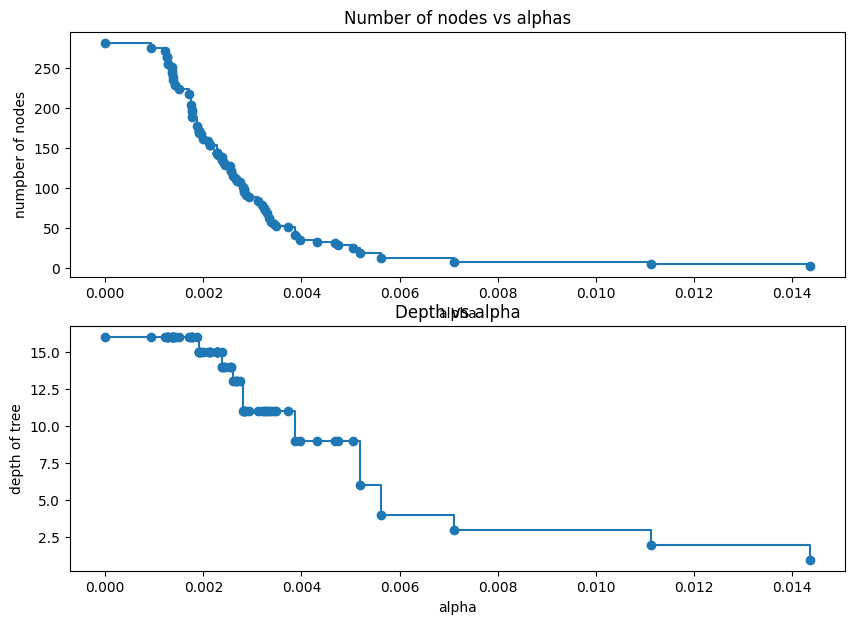

In [52]:
clfs = clfs[:-1]
ccp_alphas = ccp_alphas[:-1]

# retrieve the number of nodes for each tree
node_counts = [clf.tree_.node_count for clf in clfs]

# retrieve the depth of the each tree
depth = [clf.tree_.max_depth for clf in clfs]

# plot the alpha values against the node counts and depth
fig, ax = plt.subplots(2,1, figsize=(10,7))

# plot the first subplot ax[0]
ax[0].plot(ccp_alphas,
           node_counts,
           marker='o',
           drawstyle='steps-post')
ax[0].set_xlabel('alpha')
ax[0].set_ylabel('numpber of nodes')
ax[0].set_title('Number of nodes vs alphas')

#plot the second subplot ax[1]
ax[1].plot(ccp_alphas,
           depth,
           marker='o',
           drawstyle='steps-post')
ax[1].set_xlabel('alpha')
ax[1].set_ylabel('depth of tree')
ax[1].set_title('Depth vs alpha')
fig.tight_layout
plt.show()


## Accuracy vs alpha for training and testing sets

In [53]:
train_scores = [clf.score(X_train, y_train) for clf in clfs]
test_scores = [clf.score(X_test, y_test) for clf in clfs]

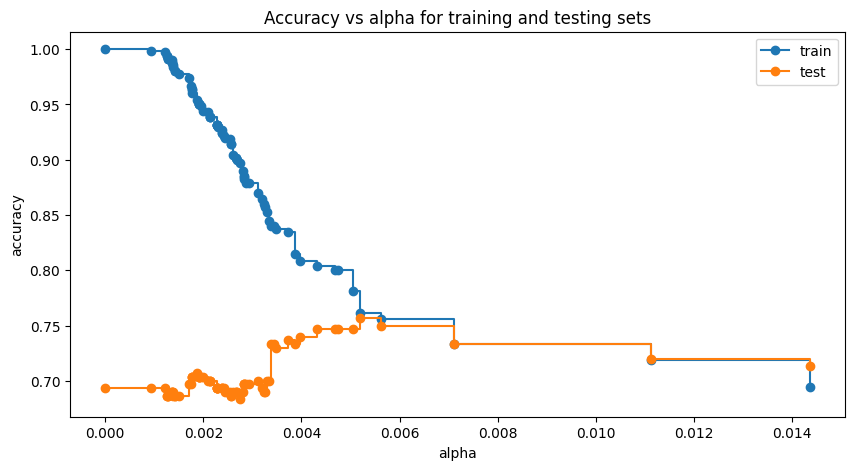

In [54]:
fig, ax = plt.subplots(figsize=(10,5))
ax.plot(ccp_alphas, 
        train_scores, 
        marker='o',
        label='train',
        drawstyle='steps-post') # use label for legend
ax.plot(ccp_alphas,
        test_scores,
        marker='o',
        label='test',
        drawstyle='steps-post')
ax.set_xlabel('alpha')
ax.set_ylabel('accuracy')
ax.set_title('Accuracy vs alpha for training and testing sets')
ax.legend()
plt.show()

In [59]:
# Find the best test model based on alpha and accuracy

# get the index value of the highest test_score of models
index_best_model = np.argmax(test_scores)
best_model = clfs[index_best_model]

print(best_model)
print('Training accuracy of best model: ',best_model.score(X_train, y_train))
print('Test accuracy of best model: ',best_model.score(X_test, y_test))

DecisionTreeClassifier(ccp_alpha=0.005203486535576088, random_state=1)
Training accuracy of best model:  0.7614285714285715
Test accuracy of best model:  0.7566666666666667


## Recall vs alphas for training and test sets

In [60]:
recall_train = []
for clf in clfs:
    pred_train3=clf.predict(X_train)
    values_train = metrics.recall_score(y_train, pred_train3)
    recall_train.append(values_train)

In [62]:
recall_test = []
for clf in clfs:
    pred_test3=clf.predict(X_test)
    values_test=metrics.recall_score(y_test, pred_test3)
    recall_test.append(values_test)

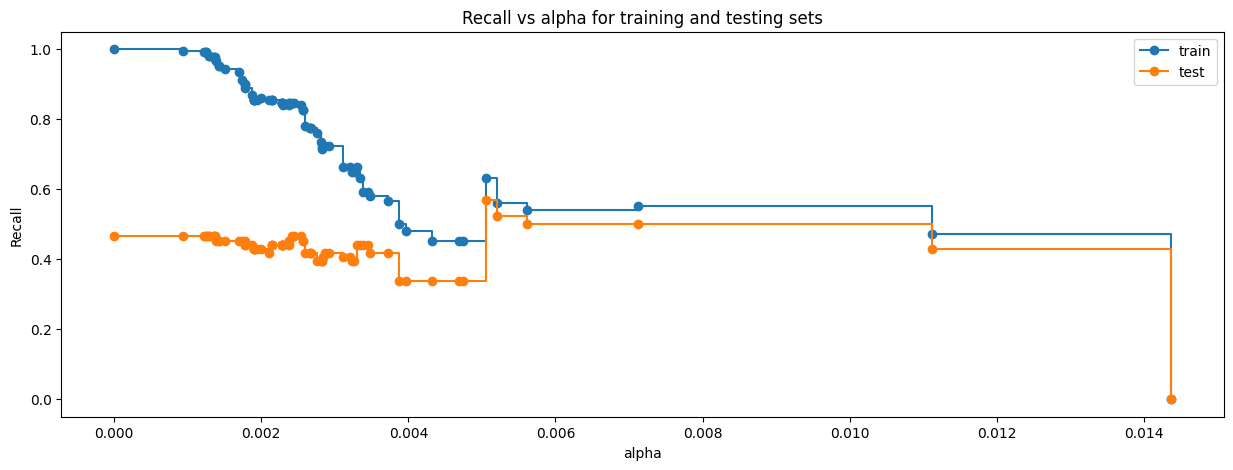

In [64]:
# plot the recall vs alphas values for training and test
fig, ax = plt.subplots(figsize=(15,5))
ax.set_xlabel("alpha")
ax.set_ylabel("Recall")
ax.set_title("Recall vs alpha for training and testing sets")
ax.plot(ccp_alphas, recall_train, marker='o', label="train",
        drawstyle="steps-post")
ax.plot(ccp_alphas, recall_test, marker='o', label="test",
        drawstyle="steps-post")
ax.legend()
plt.show()

In [65]:
# creating the model where we get highest train and test recall
index_best_model = np.argmax(recall_test)
best_model = clfs[index_best_model]
print(best_model)

DecisionTreeClassifier(ccp_alpha=0.0050611694980498625, random_state=1)


* The alphas between accuracy (0.0052) and recall (0.0051) are close to each other 

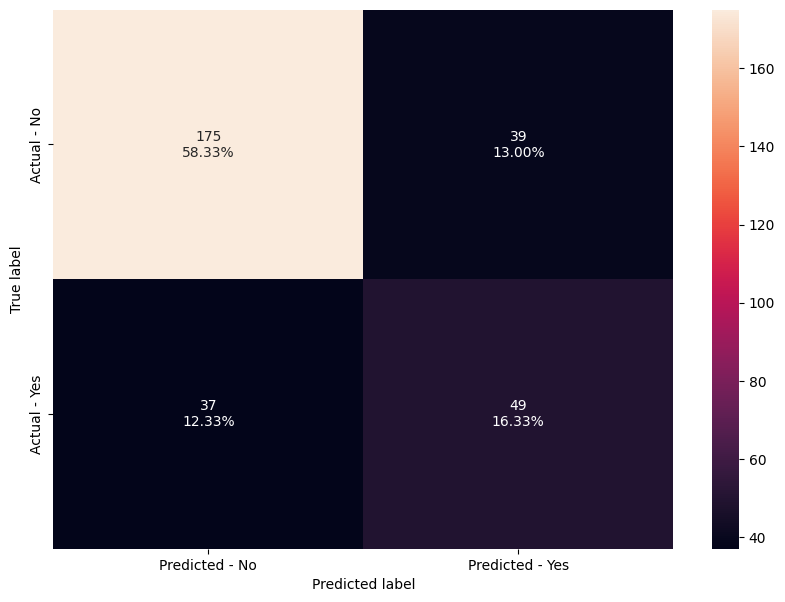

In [66]:
make_confusion_matrix(best_model,y_test)

In [67]:
# Recall on train and test
get_recall_score(best_model)

Recall on training set :  0.6308411214953271
Recall on test set :  0.5697674418604651


## Visualizing the best tree

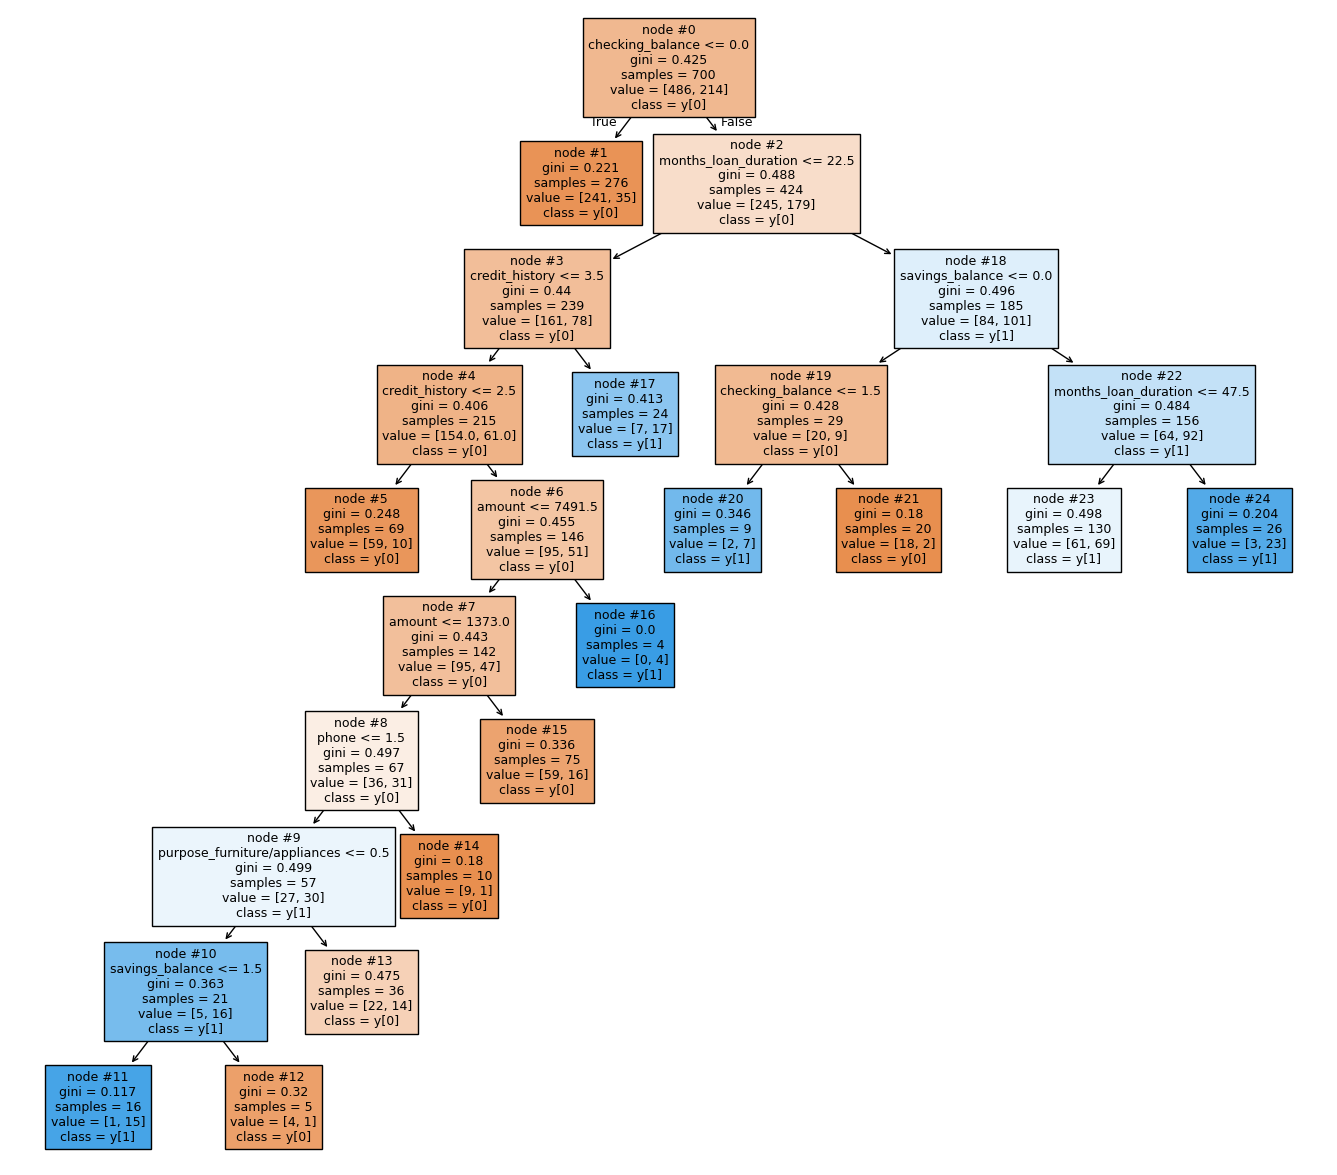

In [69]:
plt.figure(figsize=(17,15))

tree.plot_tree(best_model,
               feature_names=feature_names,
               filled=True,
               fontsize=9,
               node_ids=True,
               class_names=True)
plt.show()

In [70]:
# Text report showing the rules of a decision tree -

print(tree.export_text(best_model,
                       feature_names=feature_names,
                       show_weights=True))

|--- checking_balance <= 0.00
|   |--- weights: [241.00, 35.00] class: 0
|--- checking_balance >  0.00
|   |--- months_loan_duration <= 22.50
|   |   |--- credit_history <= 3.50
|   |   |   |--- credit_history <= 2.50
|   |   |   |   |--- weights: [59.00, 10.00] class: 0
|   |   |   |--- credit_history >  2.50
|   |   |   |   |--- amount <= 7491.50
|   |   |   |   |   |--- amount <= 1373.00
|   |   |   |   |   |   |--- phone <= 1.50
|   |   |   |   |   |   |   |--- purpose_furniture/appliances <= 0.50
|   |   |   |   |   |   |   |   |--- savings_balance <= 1.50
|   |   |   |   |   |   |   |   |   |--- weights: [1.00, 15.00] class: 1
|   |   |   |   |   |   |   |   |--- savings_balance >  1.50
|   |   |   |   |   |   |   |   |   |--- weights: [4.00, 1.00] class: 0
|   |   |   |   |   |   |   |--- purpose_furniture/appliances >  0.50
|   |   |   |   |   |   |   |   |--- weights: [22.00, 14.00] class: 0
|   |   |   |   |   |   |--- phone >  1.50
|   |   |   |   |   |   |   |--- weights: [

In [73]:
# importance feature of the best model
print(pd.DataFrame(best_model.feature_importances_,
                   columns=['Imp'],
                   index=X_train.columns)
                   .sort_values(by='Imp',
                                ascending=False))

                                   Imp
checking_balance              0.411788
months_loan_duration          0.182828
credit_history                0.138164
savings_balance               0.094024
amount                        0.093092
purpose_furniture/appliances  0.043586
phone                         0.036518
job_3                         0.000000
job_4                         0.000000
purpose_renovations           0.000000
other_credit_none             0.000000
other_credit_bank             0.000000
housing_rent                  0.000000
housing_own                   0.000000
job_1                         0.000000
housing_other                 0.000000
other_credit_store            0.000000
purpose_car0                  0.000000
purpose_education             0.000000
purpose_car                   0.000000
purpose_business              0.000000
dependents                    0.000000
existing_loans_count          0.000000
age                           0.000000
years_at_residence       

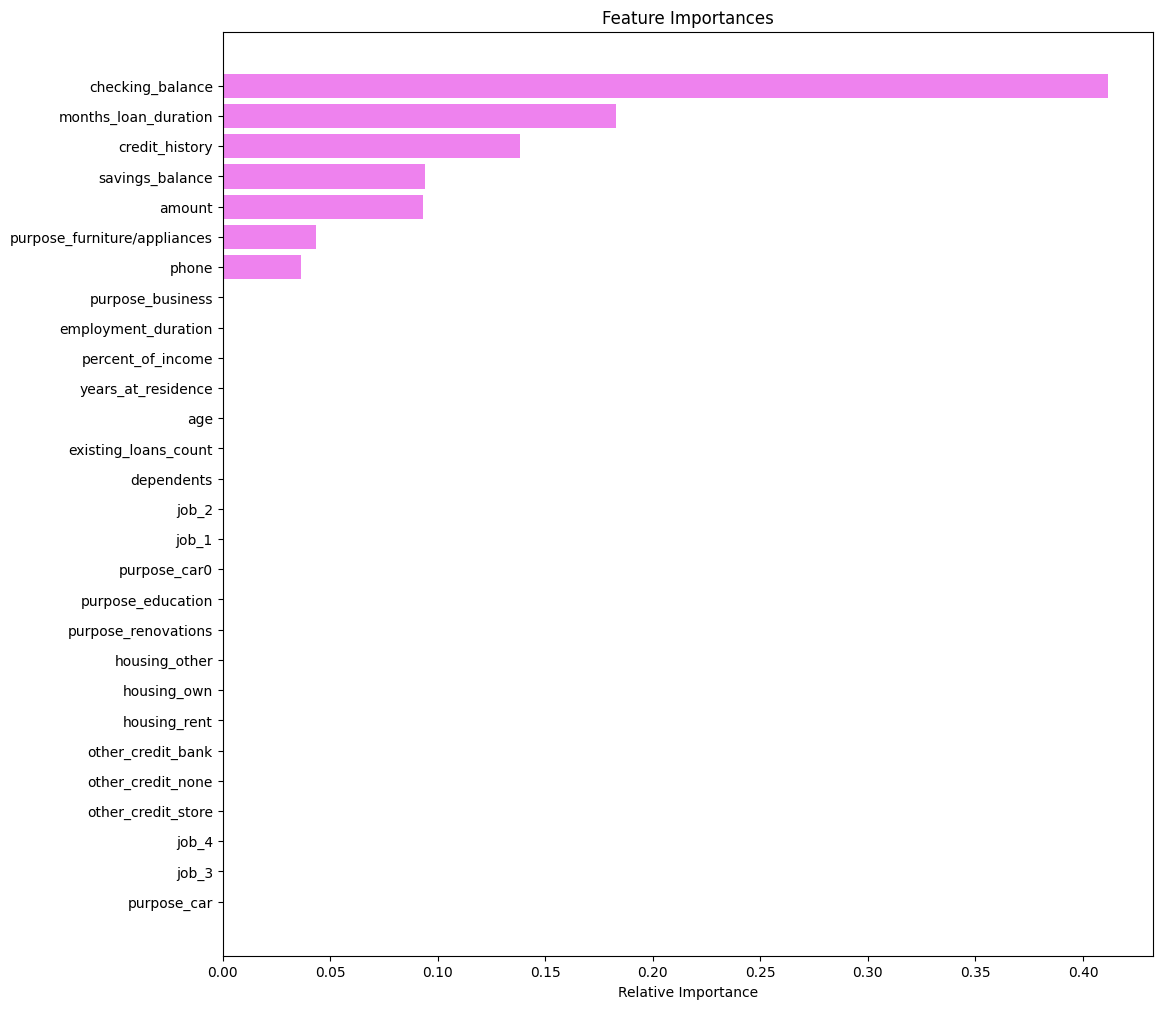

In [74]:
importances = best_model.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(12,12))
plt.title('Feature Importances')
plt.barh(range(len(indices)),
         importances[indices],
         color='violet',
         align='center')
plt.yticks(range(len(indices)),
           [feature_names[i] for i in indices])
plt.xlabel('Relative Importance')
plt.show()

## Comparing all the decision tree models

In [76]:
comparison_frame = pd.DataFrame(
    {'Model':['Initial decision tree model',
              'Decision tree with restricted max depth',
              'Decision tree with hyperparameter tuning',
              'Decision tree with post-pruning'],
     'Train Recall': [1,0.53,0.51,0.63],
     'Test Recall': [0.46,0.46,0.46,0.56]})
comparison_frame

,Model,Train Recall,Test Recall
0,Initial decision tree model,1.00,0.46
1,Decision tree with restricted max depth,0.53,0.46
2,Decision tree with hyperparameter tuning,0.51,0.46
3,Decision tree with post-pruning,0.63,0.56


* Decision tree with post-pruning provdes the highest recall on the test set